# Urban Flow Analytics — Task 2.2: On-Time Arrival Estimator
## Real-Time Pre-Trip Trip Duration & Arrival Estimation

This notebook implements the end-to-end predictive pipeline for **Task 2.2 (On-Time Arrival Estimator)**.
The objective is to accurately estimate the trip duration in minutes *before* passenger departure, providing arrival certainty for riders, dispatch planning, and fleet routing.

### Operational Framework & Key Criteria:
1. **Zero Information Leakage:** Only pre-trip observables are admitted. Target-derived variables (`base_fare`, `charge_total`, `driver_tip_payment`, `dropoff_timestamp`, `trip_speed_mph`) are strictly forbidden. Provider code and payment method are also excluded, as vehicle transit dynamics are physical routing attributes independent of commercial dispatch platforms.
2. **Chronological Splitting:** Training on historical records (Apr 2025 – Jan 2026), validation on Feb 2026, and out-of-time evaluation on March 2026.
3. **Core Evaluation Metrics:**
   - Statistical: RMSE, MAE, $R^2$, and RMSLE.
   - Operational: Tolerance bands ($\le \pm 3$ min, $\le \pm 5$ min, $\le \pm 10$ min), median absolute error, and 90th percentile error.


In [1]:
import sys
from pathlib import Path

# Set project root
project_root = Path.cwd().resolve()
if project_root.name in ("notebooks", "src", "tests"):
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import time
import duckdb
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from src.features import prepare_trip_duration_features
from src.models import (
    evaluate_duration_tolerance,
    evaluate_regression,
    load_model,
    predict_lightgbm,
    predict_xgboost,
    save_model,
    train_lightgbm,
    train_xgboost,
)
from src.utils import (
    MODELS_DIR,
    PROCESSED_DATA_DIR,
    calculate_regression_metrics,
    timer,
)

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
print("Libraries imported and runtime configured successfully.")


Libraries imported and runtime configured successfully.


## 1. Chronological Split Verification & Target Integrity

We verify that `trip_duration_minutes` is fully populated, strictly positive, and compliant with operational constraints across all chronological splits.


In [2]:
split_summary_path = PROCESSED_DATA_DIR / "split_summary.csv"
if split_summary_path.exists():
    df_splits = pd.read_csv(split_summary_path)
    display(df_splits)
else:
    print("split_summary.csv not found.")


,split,row_count,percentage
0,test,3777555,8.50
1,train,37459831,84.26
2,val,3221802,7.25


## 2. Target Variable Analysis (`trip_duration_minutes`)

We examine the distribution, median duration, and operational extremes of passenger trip times in the clean corpus.
Key patterns:
- Heavy concentration between 5 and 25 minutes for urban trips.
- Prolonged duration tails during weekday rush hours and cross-borough airport trips.


Target Variable (trip_duration_minutes) Descriptive Statistics:
count    100000.000000
mean         17.708518
std          14.620184
min           0.033000
1%            1.600000
5%            3.883000
50%          13.950000
95%          45.150000
99%          72.583340
max         789.283000
Name: trip_duration_minutes, dtype: float64


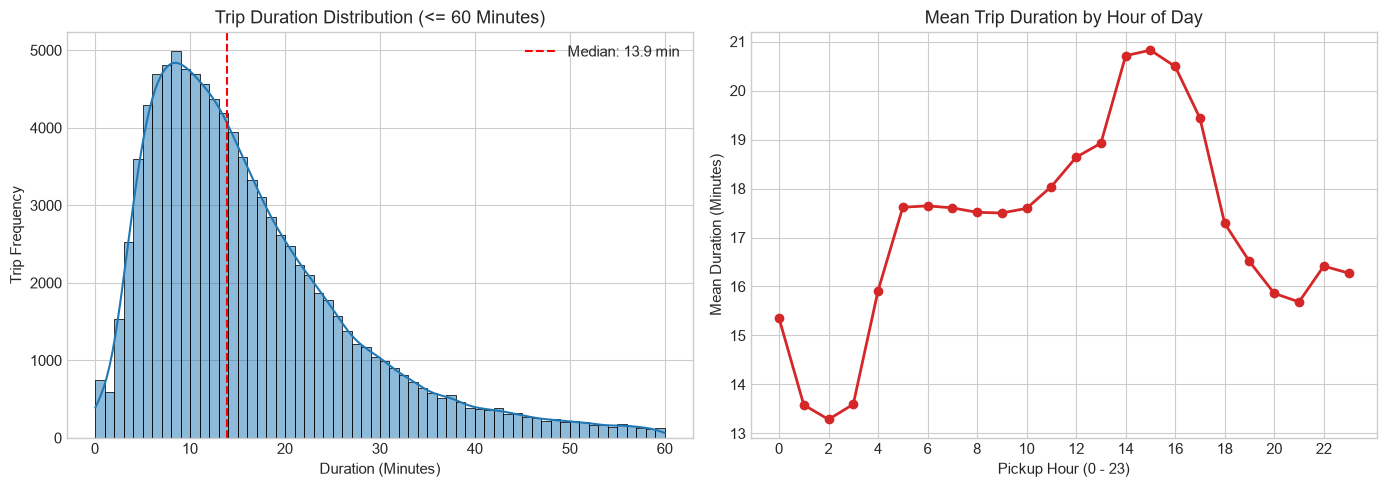

In [3]:
df_sample = pd.read_csv(PROCESSED_DATA_DIR / "train_sample.csv", nrows=100000)
dur_stats = df_sample["trip_duration_minutes"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
print("Target Variable (trip_duration_minutes) Descriptive Statistics:")
print(dur_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear distribution (up to 60 minutes)
sns.histplot(df_sample[df_sample["trip_duration_minutes"] <= 60]["trip_duration_minutes"], bins=60, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Trip Duration Distribution (<= 60 Minutes)")
axes[0].set_xlabel("Duration (Minutes)")
axes[0].set_ylabel("Trip Frequency")
axes[0].axvline(dur_stats["50%"], color="red", linestyle="--", label=f"Median: {dur_stats['50%']:.1f} min")
axes[0].legend()

# Duration by Hour of Day
hourly_dur = df_sample.groupby(pd.to_datetime(df_sample["pickup_timestamp"]).dt.hour)["trip_duration_minutes"].mean()
axes[1].plot(hourly_dur.index, hourly_dur.values, marker="o", color="#d62728", lw=2)
axes[1].set_title("Mean Trip Duration by Hour of Day")
axes[1].set_xlabel("Pickup Hour (0 - 23)")
axes[1].set_ylabel("Mean Duration (Minutes)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


## 3. Pre-Trip Feature Matrix Assembler

Features are generated strictly before trip departure using `prepare_trip_duration_features()`:
- **Routing & Pathing:** `distance_miles`, `log_distance`
- **Spatial Topology:** `origin_loc_id`, `dest_loc_id`, `is_same_zone`, `is_airport_pickup`, `is_airport_dropoff`, `is_airport_trip`, `is_ewr_trip`, `is_interborough`, `is_manhattan_intra`
- **Temporal Dynamics:** `pickup_hour`, `pickup_dayofweek`, `is_weekend`, `pickup_month`, `pickup_day`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `is_rush_hour`, `is_late_night`
- **Regulatory / Capacity:** `rate_class_id`, `is_standard_rate`, `is_jfk_flat_rate`, `is_newark_rate`, `is_negotiated_rate`, `rider_count`

**Zero Leakage Guarantee:** `base_fare`, `charge_total`, `trip_speed_mph`, `driver_tip_payment`, and `dropoff_timestamp` are strictly excluded.


In [4]:
df_train_raw = pd.read_csv(PROCESSED_DATA_DIR / "train_sample.csv")
df_val_raw = pd.read_csv(PROCESSED_DATA_DIR / "val_sample.csv")

feat_train = prepare_trip_duration_features(df_train_raw, include_target=True)
feat_val = prepare_trip_duration_features(df_val_raw, include_target=True)

X_train = feat_train.drop(columns=["trip_duration_minutes"])
y_train = feat_train["trip_duration_minutes"]
X_val = feat_val.drop(columns=["trip_duration_minutes"])
y_val = feat_val["trip_duration_minutes"]

cat_cols = ["origin_loc_id", "dest_loc_id", "rate_class_id"]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"Engineered feature count: {X_train.shape[1]}")
print("Forbidden features check:", [c for c in ["base_fare", "charge_total", "trip_speed_mph", "dropoff_timestamp"] if c in X_train.columns])


X_train shape: (100000, 28), y_train shape: (100000,)
X_val shape:   (100000, 28), y_val shape:   (100000,)
Engineered feature count: 28
Forbidden features check: []


## 4. Benchmark Model: Heuristic Speed Baseline

We establish a domain-grounded baseline: predicting trip duration from distance using historical average speed conditioned on pickup hour:
$$\hat{T}_{\text{heuristic}} = \frac{\text{distance}}{\bar{V}_{\text{hour}}} \times 60$$


In [5]:
# Compute average speed (mph) by hour on training sample
df_train_raw["speed_mph"] = (df_train_raw["distance_miles"] / np.maximum(df_train_raw["trip_duration_minutes"], 0.1)) * 60.0
hourly_speed = df_train_raw.groupby(X_train["pickup_hour"])["speed_mph"].median().to_dict()

# Predict duration on validation set
val_hours = X_val["pickup_hour"].map(hourly_speed).fillna(12.0)
naive_val_preds = (X_val["distance_miles"] / np.maximum(val_hours, 1.0)) * 60.0

naive_metrics = evaluate_regression(y_val, naive_val_preds, label="Hourly Speed Heuristic")
naive_tolerance = evaluate_duration_tolerance(y_val, naive_val_preds)

print("Naive Speed Baseline Validation Metrics:")
for k, v in naive_metrics.items():
    print(f"  {k}: {v}")
print("\nNaive Speed Baseline Tolerance Metrics:")
for k, v in naive_tolerance.items():
    print(f"  {k}: {v}")


Naive Speed Baseline Validation Metrics:
  rmse: 19.637
  mae: 9.3378
  r2: -0.8046
  rmsle: 0.5233
  mape: 43.09
  model_label: Hourly Speed Heuristic

Naive Speed Baseline Tolerance Metrics:
  pct_within_3min: 46.05
  pct_within_5min: 61.04
  pct_within_10min: 77.51
  pct_within_15min: 84.1
  median_abs_err_min: 3.43
  p90_abs_err_min: 24.49


## 5. Primary Production Model: LightGBM Duration Regressor

We train our primary LightGBM regressor on the pre-trip feature matrix using early stopping on validation RMSE.


In [6]:
with timer("Training LightGBM Duration Regressor"):
    lgb_model, imp_df, best_score = train_lightgbm(
        X_train, y_train,
        X_val, y_val,
        categorical_features=cat_cols,
        params={
            "objective": "regression",
            "metric": "rmse",
            "learning_rate": 0.08,
            "num_leaves": 63,
            "min_child_samples": 50,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "verbose": -1,
            "random_state": 42,
        },
        num_boost_round=400,
        early_stopping_rounds=40,
        verbose_eval=50,
    )

lgb_val_preds = predict_lightgbm(lgb_model, X_val, categorical_features=cat_cols)
lgb_metrics = evaluate_regression(y_val, lgb_val_preds, label="LightGBM Duration Model")
lgb_tolerance = evaluate_duration_tolerance(y_val, lgb_val_preds)

print("\nLightGBM Validation Metrics:")
for k, v in lgb_metrics.items():
    print(f"  {k}: {v}")
print("\nLightGBM Tolerance Metrics:")
for k, v in lgb_tolerance.items():
    print(f"  {k}: {v}")


[2026-09-11 01:16:35] START: Training LightGBM Duration Regressor


[50]	train's rmse: 6.74464	val's rmse: 7.88963


[100]	train's rmse: 6.18884	val's rmse: 7.82228
[150]	train's rmse: 5.86792	val's rmse: 7.82322


[2026-09-11 01:16:36] END:   Training LightGBM Duration Regressor - Elapsed: 0.88s (0.01m)

LightGBM Validation Metrics:
  rmse: 7.8122
  mae: 3.9673
  r2: 0.7144
  rmsle: 0.294
  mape: 32.52
  model_label: LightGBM Duration Model

LightGBM Tolerance Metrics:
  pct_within_3min: 59.6
  pct_within_5min: 76.82
  pct_within_10min: 91.86
  pct_within_15min: 96.25
  median_abs_err_min: 2.3
  p90_abs_err_min: 8.89


## 6. Secondary Benchmark: XGBoost Duration Regressor

We benchmark LightGBM against an XGBoost regressor on the same feature matrix to compare computational speed and tolerance accuracy.


In [7]:
with timer("Training XGBoost Duration Benchmark"):
    xgb_model, xgb_imp = train_xgboost(
        X_train, y_train,
        X_val, y_val,
        params={
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "learning_rate": 0.08,
            "max_depth": 6,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "verbosity": 0,
        },
        num_boost_round=200,
        early_stopping_rounds=30,
    )

xgb_val_preds = predict_xgboost(xgb_model, X_val)
xgb_metrics = evaluate_regression(y_val, xgb_val_preds, label="XGBoost Benchmark")
xgb_tolerance = evaluate_duration_tolerance(y_val, xgb_val_preds)

print("\nXGBoost Validation Metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v}")

# Comparison Table
comp_data = [
    {**naive_metrics, **naive_tolerance},
    {**lgb_metrics, **lgb_tolerance},
    {**xgb_metrics, **xgb_tolerance},
]
comp_df = pd.DataFrame(comp_data)
display(comp_df[["model_label", "rmse", "mae", "r2", "pct_within_3min", "pct_within_5min", "pct_within_10min", "median_abs_err_min"]])


[2026-09-11 01:16:36] START: Training XGBoost Duration Benchmark


[2026-09-11 01:16:38] END:   Training XGBoost Duration Benchmark - Elapsed: 2.19s (0.04m)

XGBoost Validation Metrics:
  rmse: 8.1949
  mae: 4.2889
  r2: 0.6857
  rmsle: 0.3131
  mape: 36.25
  model_label: XGBoost Benchmark


,model_label,rmse,mae,r2,pct_within_3min,pct_within_5min,pct_within_10min,median_abs_err_min
0,Hourly Speed Heuristic,19.6370,9.3378,-0.8046,46.05,61.04,77.51,3.43
1,LightGBM Duration Model,7.8122,3.9673,0.7144,59.60,76.82,91.86,2.30
2,XGBoost Benchmark,8.1949,4.2889,0.6857,56.07,74.11,90.66,2.54


## 7. Tolerance Band & Arrival Reliability Analysis

In urban mobility, passenger trust is driven by operational arrival certainty:
- **$\pm 3$ min:** High precision arrival for airport drop-offs and connections.
- **$\pm 5$ min:** Standard transit tolerance band for commercial dispatch.
- **$\pm 10$ min:** Extreme arrival threshold.


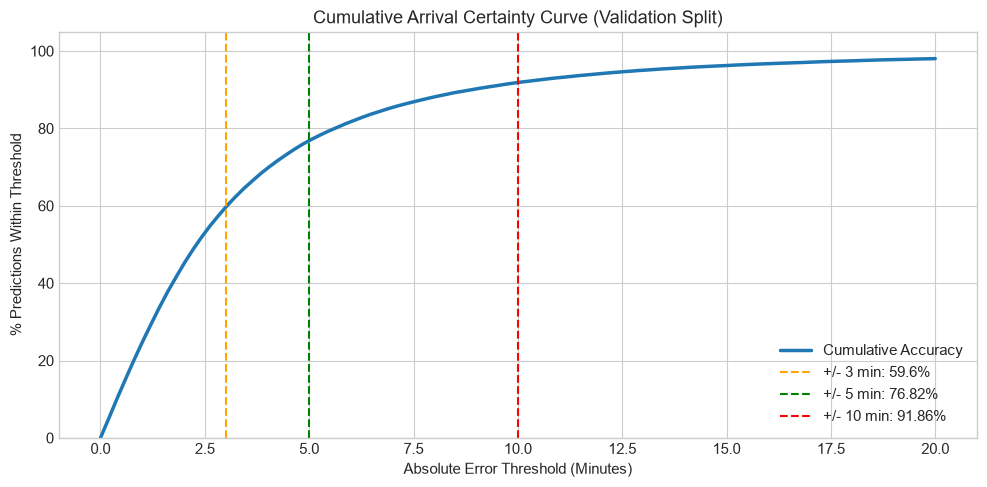

In [8]:
abs_errors = np.abs(y_val - lgb_val_preds)

# Cumulative error distribution
thresholds = np.linspace(0, 20, 100)
pct_within = [np.mean(abs_errors <= t) * 100.0 for t in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, pct_within, color="#1f77b4", lw=2.5, label="Cumulative Accuracy")
plt.axvline(3.0, color="orange", linestyle="--", label=f"+/- 3 min: {lgb_tolerance['pct_within_3min']}%")
plt.axvline(5.0, color="green", linestyle="--", label=f"+/- 5 min: {lgb_tolerance['pct_within_5min']}%")
plt.axvline(10.0, color="red", linestyle="--", label=f"+/- 10 min: {lgb_tolerance['pct_within_10min']}%")
plt.title("Cumulative Arrival Certainty Curve (Validation Split)")
plt.xlabel("Absolute Error Threshold (Minutes)")
plt.ylabel("% Predictions Within Threshold")
plt.ylim(0, 105)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 8. Sub-Group Operational Audits

To ensure operational fairness across diverse urban mobility use cases, we audit arrival accuracy across critical trip segments:
1. **Rush Hour vs. Off-Peak**
2. **Manhattan Intra-Borough vs. Inter-Borough**
3. **Airport Trips vs. Non-Airport Trips**


In [9]:
segments = {
    "Rush Hour": X_val["is_rush_hour"] == 1,
    "Off-Peak": X_val["is_rush_hour"] == 0,
    "Manhattan Intra": X_val["is_manhattan_intra"] == 1,
    "Interborough": X_val["is_interborough"] == 1,
    "Airport Trips": X_val["is_airport_trip"] == 1,
    "Non-Airport Trips": X_val["is_airport_trip"] == 0,
}

audit_rows = []
for seg_name, mask in segments.items():
    if mask.sum() > 0:
        sub_y = y_val[mask]
        sub_pred = lgb_val_preds[mask]
        m = evaluate_regression(sub_y, sub_pred, label=seg_name)
        t = evaluate_duration_tolerance(sub_y, sub_pred)
        audit_rows.append({
            "Segment": seg_name,
            "Sample Count": mask.sum(),
            "RMSE": m["rmse"],
            "MAE": m["mae"],
            "R2": m["r2"],
            "+/- 5 min (%)": t["pct_within_5min"],
            "Median Abs Err (min)": t["median_abs_err_min"],
        })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)


,Segment,Sample Count,RMSE,MAE,R2,+/- 5 min (%),Median Abs Err (min)
0,Rush Hour,34906,7.6849,4.3146,0.7516,74.13,2.49
1,Off-Peak,65094,7.8796,3.7811,0.6902,78.27,2.20
2,Manhattan Intra,80035,5.2179,3.1097,0.6387,82.43,2.01
3,Interborough,14171,14.9775,8.1541,0.5388,49.64,5.05
4,Airport Trips,7154,12.3032,6.6355,0.6293,54.72,4.41
5,Non-Airport Trips,92846,7.3532,3.7618,0.6801,78.52,2.20


## 9. Out-of-Time Test Split Evaluation (March 2026)

We evaluate the finalized LightGBM duration estimator on unseen March 2026 trip records to prove operational stability under evolving urban traffic conditions.


Final Out-of-Time Test Metrics (Task 2.2 - Trip Duration):
  rmse: 7.0129
  mae: 3.602
  r2: 0.7794
  rmsle: 0.2715
  mape: 33.65
  model_label: LightGBM Out-of-Time Test (March 2026)

Final Out-of-Time Test Tolerance Metrics:
  pct_within_3min: 63.59
  pct_within_5min: 80.8
  pct_within_10min: 93.54
  pct_within_15min: 96.89
  median_abs_err_min: 2.11
  p90_abs_err_min: 7.69


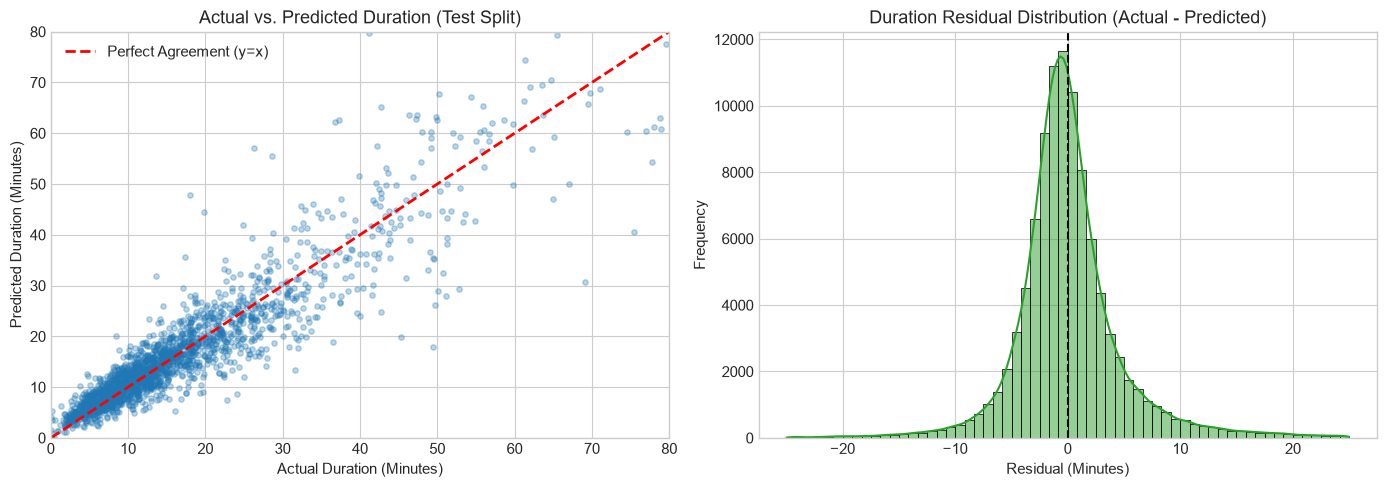

In [10]:
df_test_raw = pd.read_csv(PROCESSED_DATA_DIR / "test_sample.csv")
feat_test = prepare_trip_duration_features(df_test_raw, include_target=True)
X_test = feat_test.drop(columns=["trip_duration_minutes"])
y_test = feat_test["trip_duration_minutes"]

lgb_test_preds = predict_lightgbm(lgb_model, X_test, categorical_features=cat_cols)
test_metrics = evaluate_regression(y_test, lgb_test_preds, label="LightGBM Out-of-Time Test (March 2026)")
test_tolerance = evaluate_duration_tolerance(y_test, lgb_test_preds)

print("Final Out-of-Time Test Metrics (Task 2.2 - Trip Duration):")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")
print("\nFinal Out-of-Time Test Tolerance Metrics:")
for k, v in test_tolerance.items():
    print(f"  {k}: {v}")

# Residual Visualization
dur_residuals = y_test - lgb_test_preds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test[:2000], lgb_test_preds[:2000], alpha=0.3, s=15, color="#1f77b4")
axes[0].plot([0, 80], [0, 80], "r--", lw=2, label="Perfect Agreement (y=x)")
axes[0].set_xlim(0, 80)
axes[0].set_ylim(0, 80)
axes[0].set_xlabel("Actual Duration (Minutes)")
axes[0].set_ylabel("Predicted Duration (Minutes)")
axes[0].set_title("Actual vs. Predicted Duration (Test Split)")
axes[0].legend()

# Residual distribution
sns.histplot(dur_residuals[(dur_residuals >= -25) & (dur_residuals <= 25)], bins=60, kde=True, ax=axes[1], color="#2ca02c")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Duration Residual Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual (Minutes)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 10. Model Interpretability & Dominant Feature Drivers

We analyze Gain-based feature attribution to explain the primary physical and temporal factors dictating trip duration.


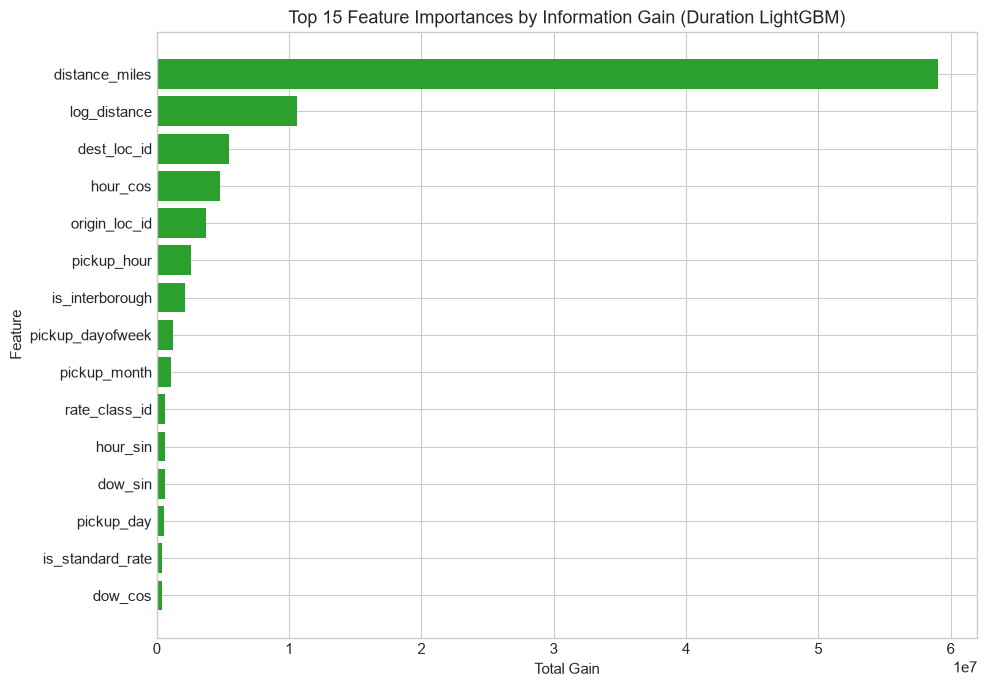

Top 10 Drivers of Trip Duration:


,feature,importance_gain,importance_split
0,distance_miles,5.903870e+07,1375
1,log_distance,1.060678e+07,273
2,dest_loc_id,5.426063e+06,1614
3,hour_cos,4.761160e+06,477
4,origin_loc_id,3.724132e+06,1398
5,pickup_hour,2.600278e+06,603
6,is_interborough,2.132378e+06,141
7,pickup_dayofweek,1.232864e+06,338
8,pickup_month,1.071886e+06,513
9,rate_class_id,6.437338e+05,118


In [11]:
plt.figure(figsize=(10, 7))
top_imp = imp_df.head(15).sort_values(by="importance_gain", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance_gain"], color="#2ca02c")
plt.title("Top 15 Feature Importances by Information Gain (Duration LightGBM)")
plt.xlabel("Total Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 Drivers of Trip Duration:")
display(imp_df.head(10)[["feature", "importance_gain", "importance_split"]])


## 11. Model Serialization & Production Artifact Deployment

We serialize the finalized duration estimator into `models/duration_lgbm.pkl` with complete schema and tolerance benchmarks.


In [12]:
model_export_path = MODELS_DIR / "duration_lgbm.pkl"
metadata = {
    "task": "trip_duration_prediction",
    "model_type": "LightGBM_Booster",
    "features": lgb_model.feature_name(),
    "categorical_features": cat_cols,
    "validation_metrics": lgb_metrics,
    "validation_tolerance": lgb_tolerance,
    "test_metrics": test_metrics,
    "test_tolerance": test_tolerance,
    "version": "1.0.0",
}
save_path = save_model(lgb_model, model_export_path, metadata=metadata)
print(f"Duration model successfully saved to: {save_path}")

# Verify reload
loaded_model, loaded_meta = load_model(save_path)
verification_preds = predict_lightgbm(loaded_model, X_test.head(10), categorical_features=cat_cols)
print("Reloaded model verification predictions (first 5):", np.round(verification_preds[:5], 2))
print("Serialization test PASSED.")


Duration model successfully saved to: C:\Users\ASUS\Desktop\datathon\nexora-datathon2026\models\duration_lgbm.pkl
Reloaded model verification predictions (first 5): [15.99 11.95 13.19 11.99 62.55]
Serialization test PASSED.
